## Baseline: Metropolis Monte Carlo for a 1D potential

Before implementing event-chain methods, we first consider a simple Metropolis sampler for a one-dimensional target distribution

$$
\pi(x) \propto e^{-x^2}.
$$

This corresponds to the potential

$$
U(x)=x^2
$$

at temperature $T=1$. The purpose of this example is to provide a simple baseline for understanding proposal size, acceptance rate, burn-in, and sample autocorrelation.

In [1]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random

# set random seed for reproducibility
random.seed(42)
np.random.seed(42)

In [2]:
def potential(x):
    """
    Calculate the potential energy at a given position.

    Args:
        x (float): The position at which to calculate the potential energy.

    Returns:
        float: The potential energy at the given position.
    """
    return x**2

def potential_difference(current_x, proposed_x, single=True, double=False):
    """
    Calculate the difference in potential energy between the current and proposed positions.

    Args:
        current_x (float): The current position.
        proposed_x (float): The proposed position.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        float: The difference in potential energy between the two positions.
    """
    if single:
        return potential(proposed_x) - potential(current_x)
    if double: 
        return U_double_well(proposed_x) - U_double_well(current_x)
    else:
        raise ValueError("Either 'single' or 'double' must be True.")

In [3]:
def propose_move(current_x, proposal_width):
    """_summary_

    Args:
        current_x (float): The current position.
        proposal_width (float): The width of the proposal distribution.

    Returns:
        float: The proposed position.
    """
    noise = random.uniform(-proposal_width / 2, proposal_width / 2)
    return current_x + noise

In [4]:
def accept_move(delta_potential, temperature):
    """
    Calculate whether to accept a proposed move.

    Args:
        delta_potential (float): The difference in potential energy between the current and proposed positions.
        temperature (float): The temperature of the system.
    Returns:
        bool: True if the proposed move should be accepted, False otherwise.
    """
    acceptance_prob = min(1, np.exp(-delta_potential / temperature))
    return np.random.rand() < acceptance_prob

In [5]:
def metropolis_step(current_x, proposal_width, temperature, single=True, double=False):
    """
    Perform a single Metropolis step.

    Args:
        current_x (float): The current position.
        proposal_width (float): The width of the proposal distribution.
        temperature (float): The temperature of the system.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        tuple: A tuple containing the new position after the Metropolis step and a boolean indicating whether the move was accepted.
    """
    proposed_x = propose_move(current_x, proposal_width)
    delta_potential = potential_difference(current_x, proposed_x, single=single, double=double)
    
    accepted = accept_move(delta_potential, temperature)
    return (proposed_x, True) if accepted else (current_x, False)

def metropolis_run(initial_x, num_steps, proposal_width, temperature, single=True, double=False):
    """
    Run the Metropolis algorithm for a given number of steps.   

    Args:
        initial_x (float): The initial position of the system.
        num_steps (int): The number of steps to run the algorithm.
        proposal_width (float): The width of the proposal distribution.
        temperature (float): The temperature of the system.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        tuple: A tuple containing an array of positions visited during the simulation and the acceptance rate.
    """

    positions = [initial_x]
    current_x = initial_x
    accepted_moves = 0
    
    for _ in range(num_steps):
        current_x, accepted = metropolis_step(current_x, proposal_width, temperature, single=single, double=double)
        
        if accepted:
            accepted_moves += 1
            
        positions.append(current_x)
        
    acceptance_rate = accepted_moves / num_steps
    
    return np.array(positions), acceptance_rate

In [6]:
def target_distribution(x_grid, potential_func, temperature):
    """
    Calculate the target distribution for a given position.

    Args:
        x_grid (np.ndarray): The grid of x values over which to evaluate the target distribution.
        potential_func (callable): The potential function.
        temperature (float): The temperature parameter.

    Returns:
        np.ndarray: The values of the target distribution at the given positions.
    """
    weights = np.exp(-potential_func(x_grid) / temperature)
    normalisation = np.trapezoid(weights, x_grid)
    return weights / normalisation
    

def plot_trajectory_and_histogram(trajectory, acceptance_rate, burn_in, potential_func, temperature, title_suffix, x_min=-5, x_max=5, bins=50):
    """
    Plot the trajectory and histogram of sampled positions for a given trajectory.

    Args:
        trajectory (np.ndarray): The trajectory of positions.
        acceptance_rate (float): The acceptance rate of the Metropolis algorithm.
        burn_in (int): The number of initial steps to discard as burn-in.
        potential_func (callable): The potential function to plot the theoretical distribution.
        temperature (float): The temperature parameter.
        title_suffix (str): Suffix to add to the plot titles for differentiation.
    """
    samples = trajectory[burn_in:]

    plt.figure(figsize=(12, 8))
    plt.plot(trajectory)
    plt.axvline(burn_in, linestyle="--", label="Burn-in cutoff")
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.title(f"Metropolis trajectory {title_suffix}, acceptance rate = {acceptance_rate:.3f}")
    plt.grid()
    plt.legend()
    plt.show()

    x = np.linspace(x_min, x_max, 1000)
    theoretical_dist = target_distribution(x, potential_func, temperature)

    plt.figure(figsize=(12, 8))
    plt.hist(samples, bins=bins, density=True, alpha=0.7, label="Sampled distribution")
    plt.plot(x, theoretical_dist, color='red', label="Theoretical distribution")
    plt.xlabel("Position")
    plt.ylabel("Probability Density")
    plt.title(f"Histogram of sampled positions {title_suffix}")
    plt.grid()
    plt.legend()
    plt.show()

Acceptance Rate: 72.87%


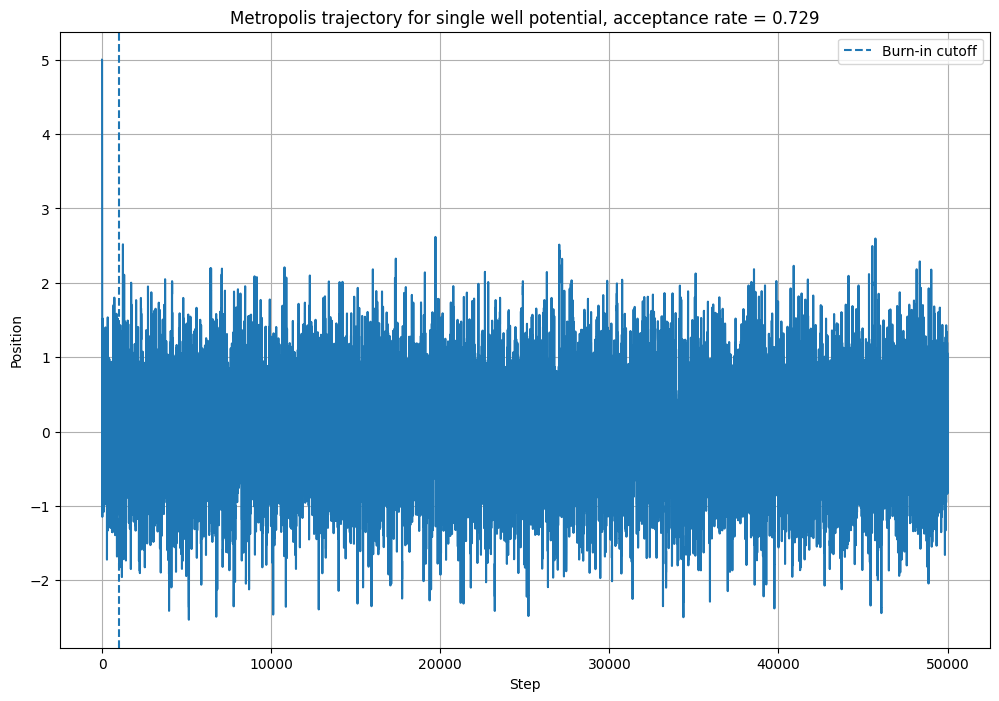

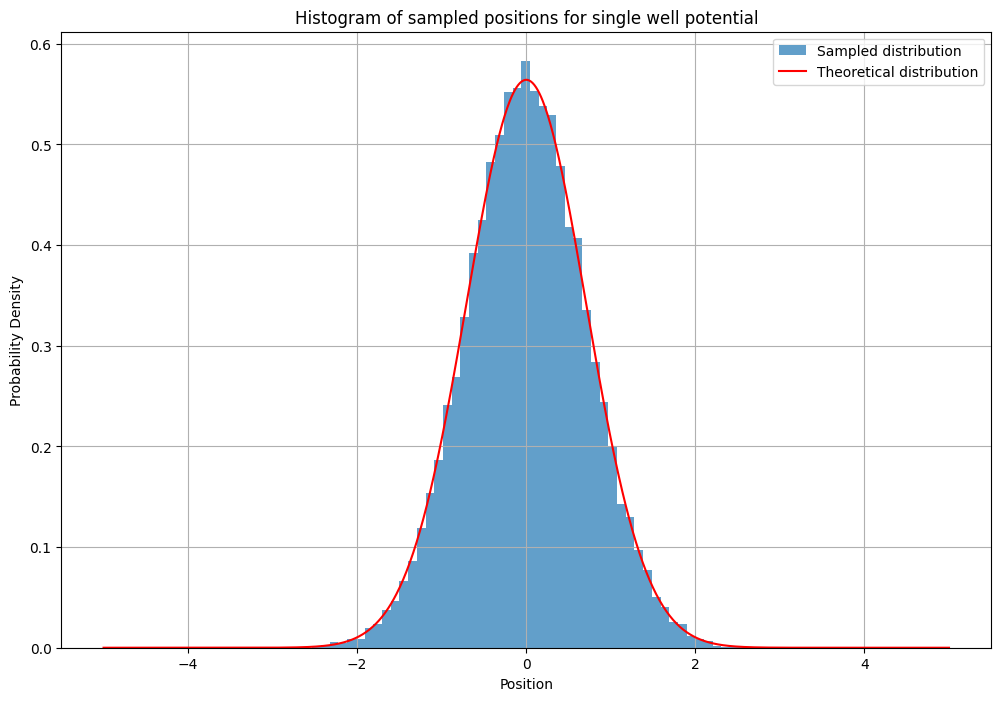

In [7]:
temperature = 1.0

trajectory, acceptance_rate = metropolis_run(
    initial_x=5.0,
    num_steps=50_000,
    proposal_width=2.0,
    temperature=temperature,
)
print(f"Acceptance Rate: {acceptance_rate:.2%}")

burn_in = 1000

plot_trajectory_and_histogram(
    trajectory,
    acceptance_rate,
    burn_in,
    potential,
    temperature,
    "for single well potential",
    x_min=-5,
    x_max=5
)

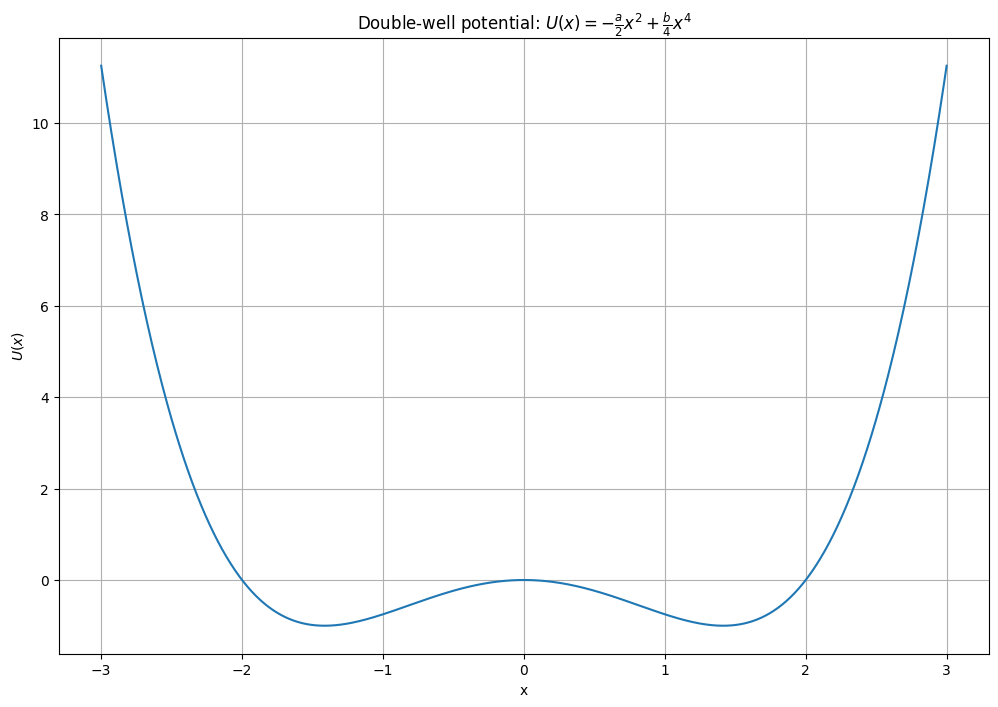

In [8]:
def U_double_well(x, a=2.0, b=1.0):
    """
    Calculate the potential energy for a double well potential at a given position.

    Args:
        x (float): The position at which to calculate the potential energy.
        a (float): The depth of the wells.
        b (float): The barrier height.
    """
    return -(a/2)*x**2 + (b/4)*x**4

x = np.linspace(-3, 3, 1000)

plt.figure(figsize=(12, 8))
plt.plot(x, U_double_well(x))
plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title(r"Double-well potential: $U(x)= -\frac{a}{2}x^{2} + \frac{b}{4}x^{4}$")
plt.grid()
plt.show()

### Double-well potential

We consider

$$U(x) = -\frac{ax^2}{2} + \frac{bx^4}{4}$$

with $a = 2$ and $b = 1$. This potential has two minima at $x = \pm \sqrt{2}$ and a potential barrier at $x = 0$.

Acceptance Rate: 85.56%


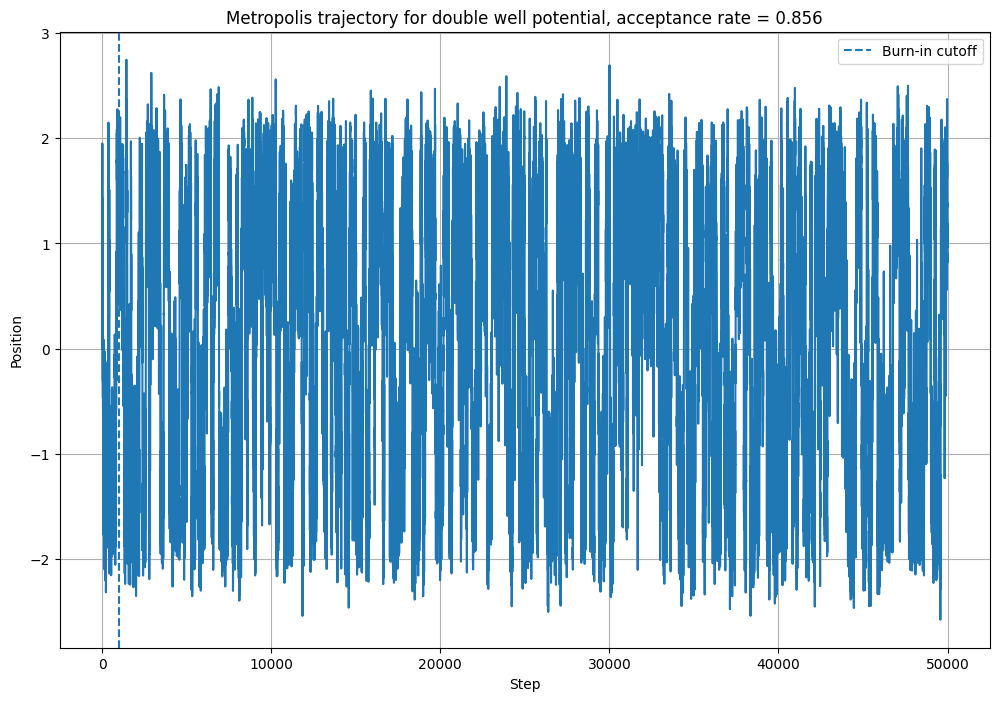

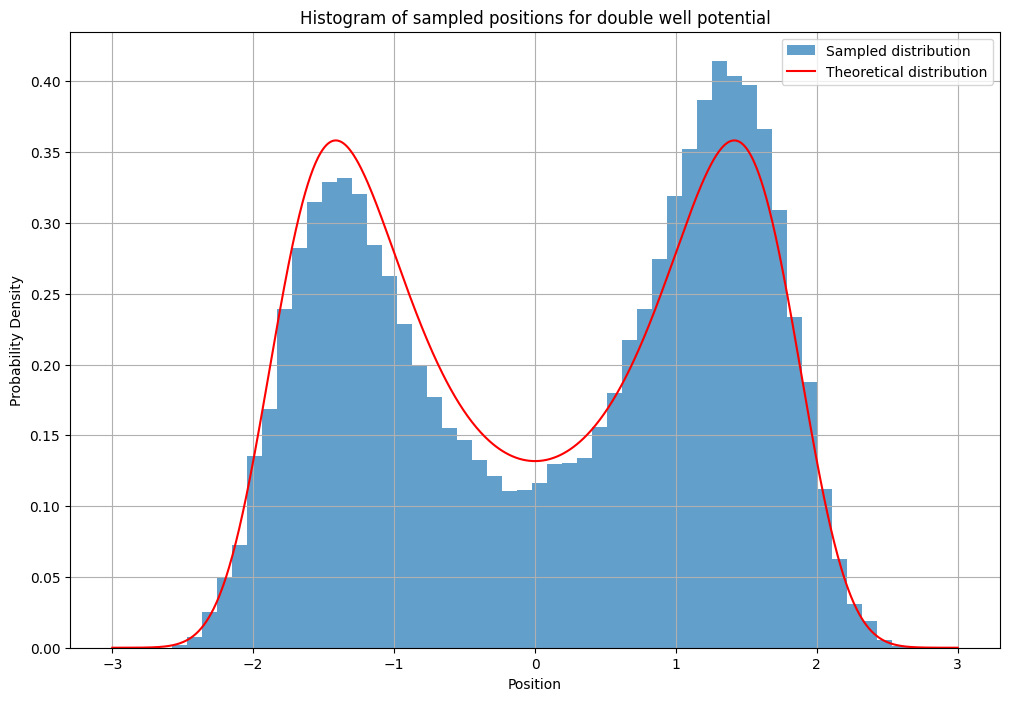

In [9]:
temperature = 1.0

trajectory_double, acceptance_rate_double = metropolis_run(
    initial_x=0.0,
    num_steps=50000,
    proposal_width=1.0,
    temperature=temperature,
    single=False,
    double=True
)

print(f"Acceptance Rate: {acceptance_rate_double:.2%}")

plot_trajectory_and_histogram(
    trajectory_double,
    acceptance_rate_double,
    burn_in,
    U_double_well,
    temperature,
    "for double well potential",
    x_min=-3,
    x_max=3
)

The histogram agrees reasonably well with the normalised target density

$$
\pi_T(x) \propto \exp\left(-\frac{U(x)}{T}\right).
$$

For the double-well potential, the two peaks occur near the minima

$$
x = \pm \sqrt{2},
$$

while the lower probability near $x=0$ corresponds to the potential barrier between the wells. The Metropolis chain is able to move between both wells at $T=1$, so at this temperature the barrier is not yet too restrictive. However, at lower temperatures, barrier crossing should become harder, and the chain may spend longer periods trapped in one well.

T = 1.0
Acceptance Rate: 85.65%


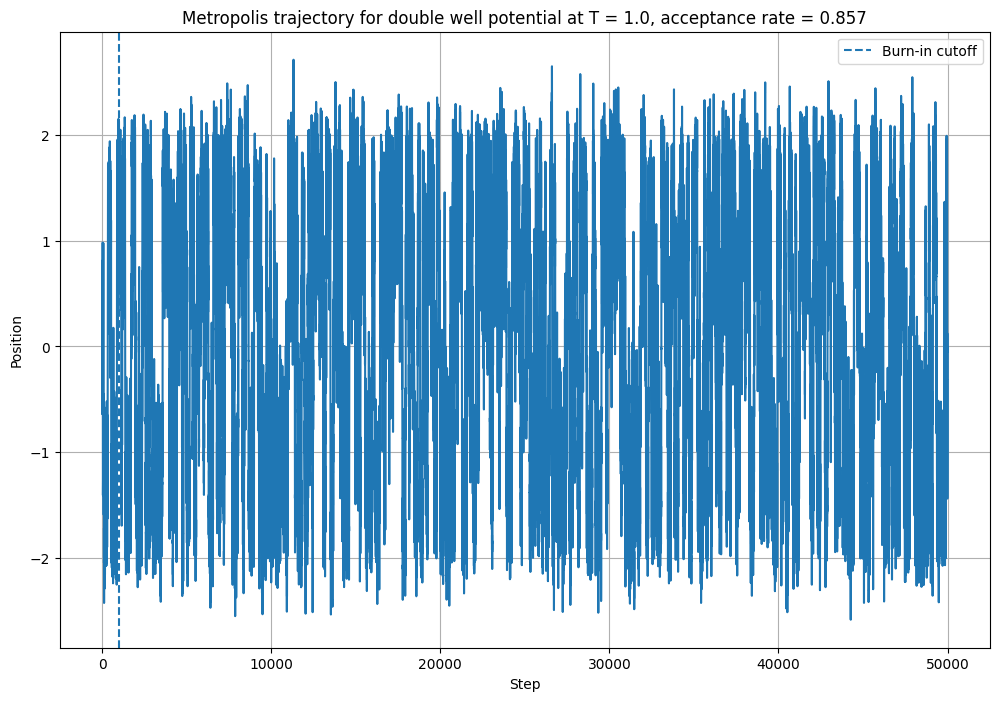

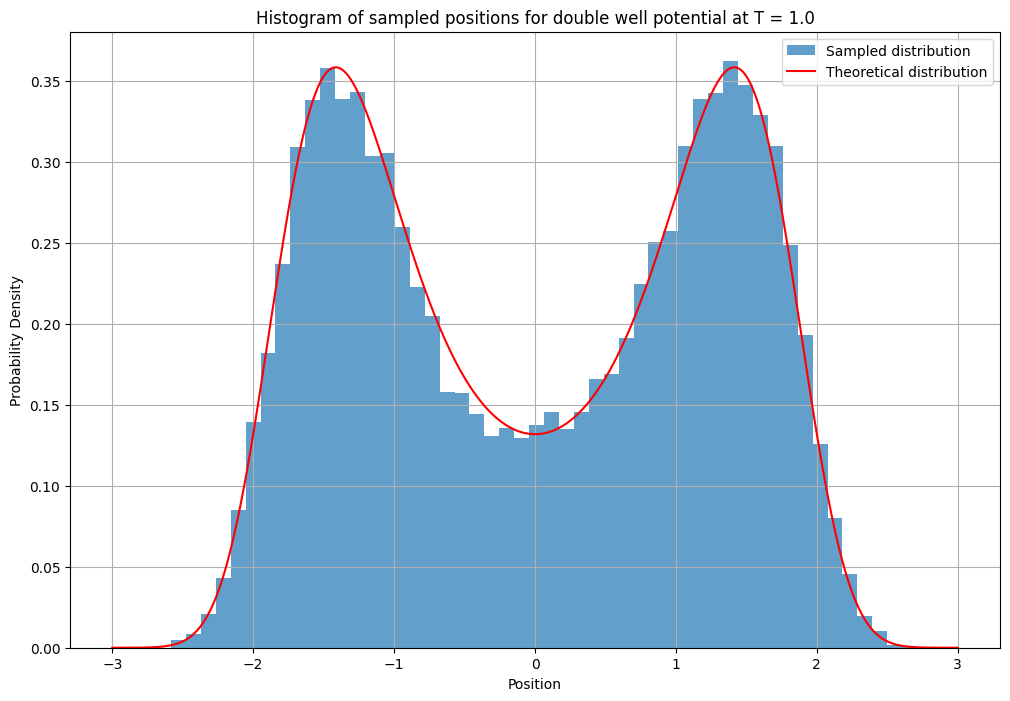

T = 0.5
Acceptance Rate: 77.46%


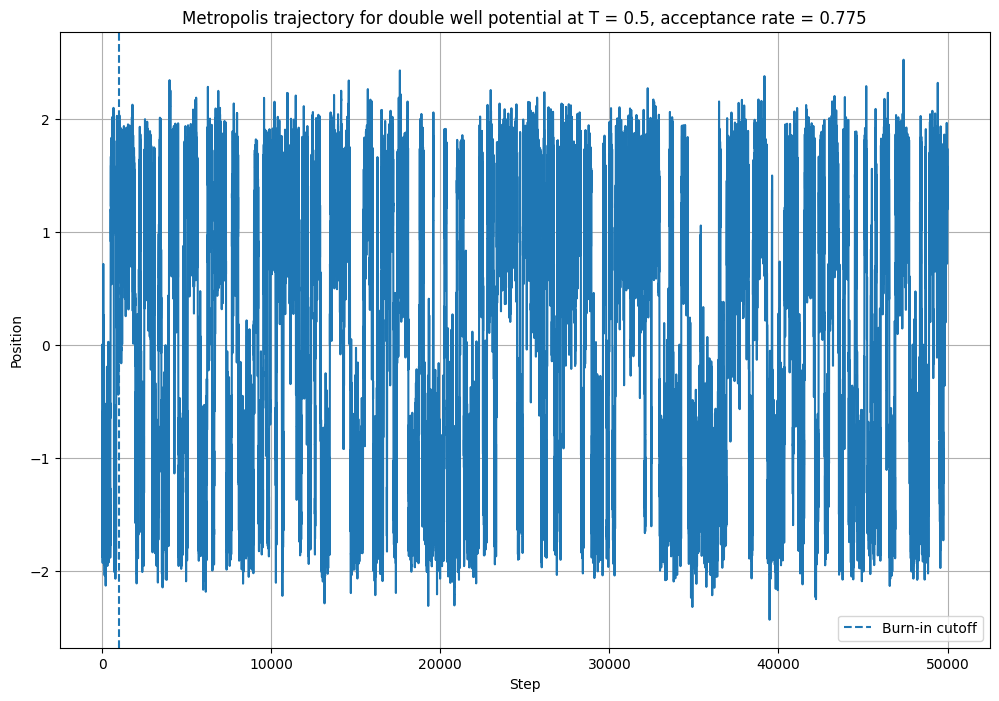

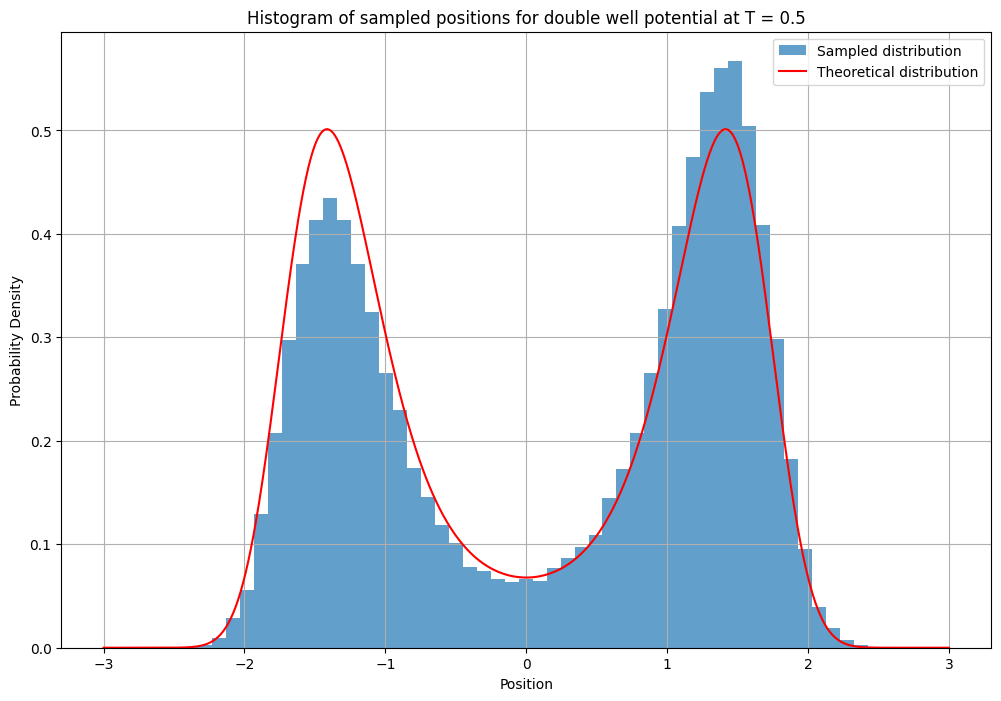

T = 0.2
Acceptance Rate: 61.62%


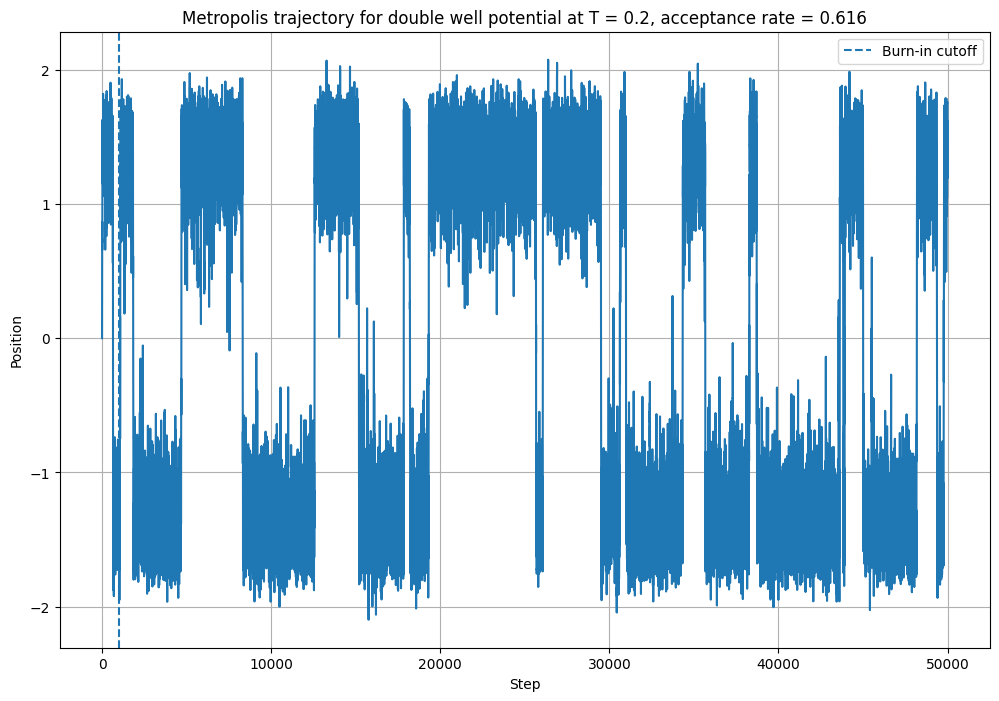

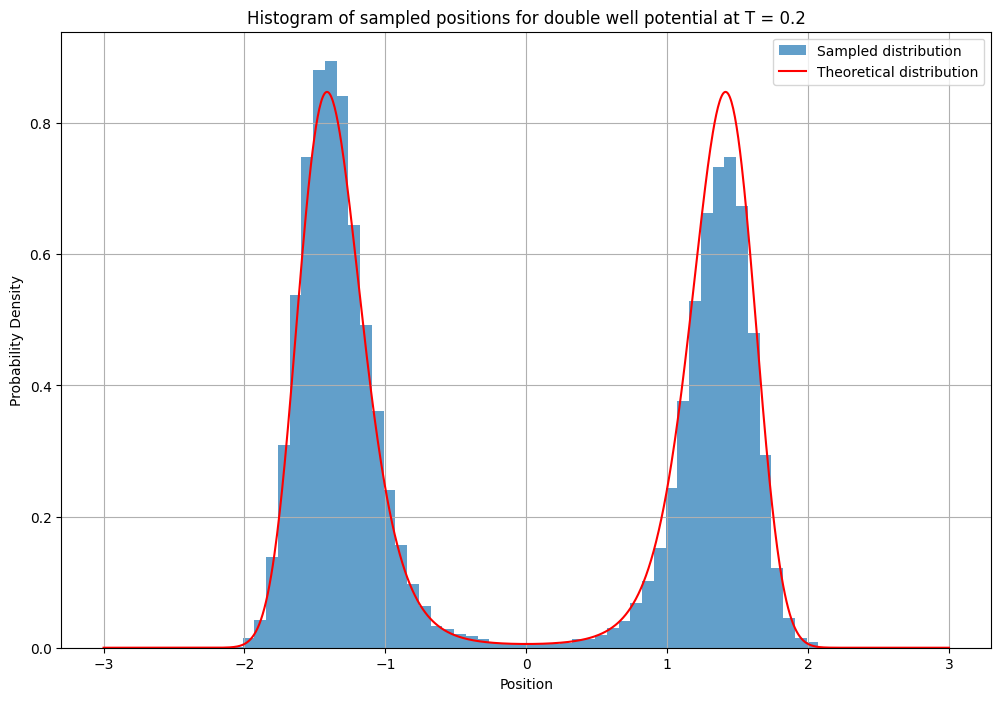

In [10]:
temperatures = [1.0, 0.5, 0.2]

for temperature in temperatures:
    trajectory_double_T, acceptance_rate_double_T = metropolis_run(
        initial_x=0.0,
        num_steps=50000,
        proposal_width=1.0,
        temperature=temperature,
        single=False,
        double=True
    )

    print(f"T = {temperature}")
    print(f"Acceptance Rate: {acceptance_rate_double_T:.2%}")

    plot_trajectory_and_histogram(
        trajectory_double_T,
        acceptance_rate_double_T,
        burn_in,
        U_double_well,
        temperature,
        f"for double well potential at T = {temperature}",
        x_min=-3,
        x_max=3
    )

At temperature $T$, the target density is

$$
\pi_T(x) \propto \exp\left(-\frac{U(x)}{T}\right).
$$

At $T=1.0$, the Metropolis chain explores both wells reasonably well and the empirical histogram agrees with the normalised target density. At $T=0.5$, the target distribution becomes more concentrated around the two minima, but the chain still switches between the wells often enough to give a reasonable histogram.

At $T=0.2$, the behaviour changes noticeably. The trajectory contains long periods where the chain remains in one well before crossing to the other. The empirical histogram is therefore less symmetric and no longer matches the theoretical target as well. This suggests that the main difficulty at low temperature is not simply low acceptance rate, but poor mode switching caused by the potential barrier at $x=0$.

In [11]:
def thin_samples(samples, thinning_factor):
    """
    Thin the samples by keeping every nth sample.

    Args:
        samples (np.ndarray): The array of samples to thin.
        thinning_factor (int): The factor by which to thin the samples.

    Returns:
        np.ndarray: The thinned array of samples.
    """
    return samples[::thinning_factor]

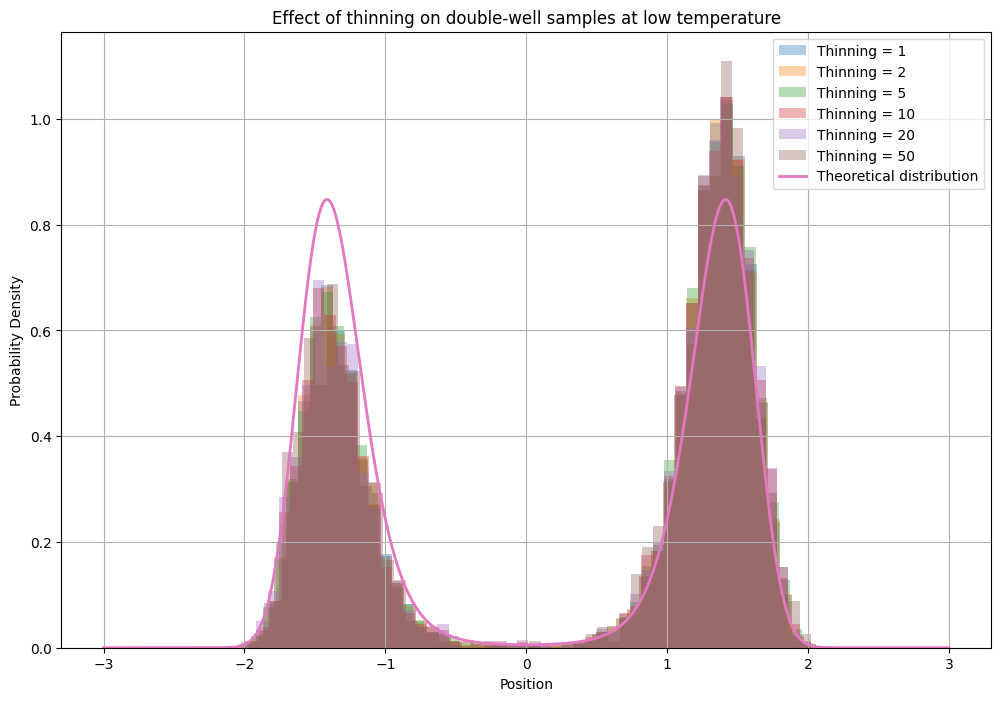

In [12]:
temperature = 0.2

trajectory_double_lowT, acceptance_rate_double_lowT = metropolis_run(
    initial_x=0.0,
    num_steps=50000,
    proposal_width=1.0,
    temperature=temperature,
    single=False,
    double=True
)

samples_lowT = trajectory_double_lowT[burn_in:]

thinning_values = [1, 2, 5, 10, 20, 50]

plt.figure(figsize=(12, 8))

for thinning in thinning_values:
    thinned_samples = thin_samples(samples_lowT, thinning)
    plt.hist(
        thinned_samples,
        bins=50,
        density=True,
        alpha=0.35,
        label=f"Thinning = {thinning}"
    )

x = np.linspace(-3, 3, 1000)
theoretical_dist = target_distribution(x, U_double_well, temperature)

plt.plot(x, theoretical_dist, linewidth=2, label="Theoretical distribution")
plt.xlabel("Position")
plt.ylabel("Probability Density")
plt.title("Effect of thinning on double-well samples at low temperature")
plt.grid()
plt.legend()
plt.show()

Thinning keeps every $n$-th sample from the Markov chain. This can make the stored samples appear less correlated, but it does not fix poor mixing by itself. In the low-temperature double-well case, the main issue is that the chain can spend long periods trapped in one well. Thinning reduces the number of stored points from these trapped regions, but if the original trajectory has not crossed the barrier often enough, the thinned histogram can still be biased.

## Event-chain Monte Carlo for the single well

I now implement ECMC for the same single-well potential used in the Metropolis baseline,

$$
U(x)=x^2.
$$

For this potential,

$$
\frac{dU}{dx}=2x.
$$

In one dimension, the ECMC dynamics moves the particle with velocity $v=\pm 1$ until an event occurs. The event rate is

$$
\lambda(x,v)=\max\left(0,v\frac{dU}{dx}\right)=\max(0,2vx).
$$

This means that only uphill movement contributes to the event rate. When an event occurs, the velocity is reversed. This gives a nonreversible alternative to the random proposal moves used in Metropolis MC.

In [13]:
def distance_to_next_event_single_well(current_x, velocity, temperature):
    """
    Calculate the distance to the next event in a single well potential.

    Args:
        current_x (float): The current position of the particle.
        velocity (float): The velocity of the particle.
        temperature (float): The temperature of the system.

    Returns:
        float: The distance to the next event.
    """
    
    u = 1.0 - np.random.rand()
    uphill_energy = -temperature * np.log(u)

    # Convert to coordinate moving in direction of velocity
    y0 = velocity * current_x

    # If y0 < 0, the particle is moving downhill until it reaches x=0.
    # After that, it starts moving uphill.
    if y0 < 0:
        distance_to_minimum = -y0
        uphill_distance = np.sqrt(uphill_energy)
        return distance_to_minimum + uphill_distance

    # If y0 >= 0, it is already moving uphill.
    # Need (y0 + s)^2 - y0^2 = uphill_energy.
    return np.sqrt(y0**2 + uphill_energy) - y0

In [14]:
def ecmc_run_single_well(initial_x, num_samples, distance_between_samples, temperature):
    """
    Run the ECMC algorithm for a single well potential.

    Args:
        initial_x (float): The initial position of the particle.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between consecutive samples.
        temperature (float): The temperature of the system.

    Returns:
        np.ndarray: An array of the generated sample positions.
    """
    current_x = initial_x
    velocity = np.random.choice([-1, 1])

    positions = [current_x]

    for _ in range(num_samples):
        distance_to_next_sample = distance_between_samples

        while distance_to_next_sample > 0:
            distance_to_event = distance_to_next_event_single_well(
                current_x,
                velocity,
                temperature
            )

            if distance_to_event < distance_to_next_sample:
                current_x += velocity * distance_to_event
                distance_to_next_sample -= distance_to_event
                velocity *= -1
            else:
                current_x += velocity * distance_to_next_sample
                distance_to_next_sample = 0

        positions.append(current_x)

    return np.array(positions)

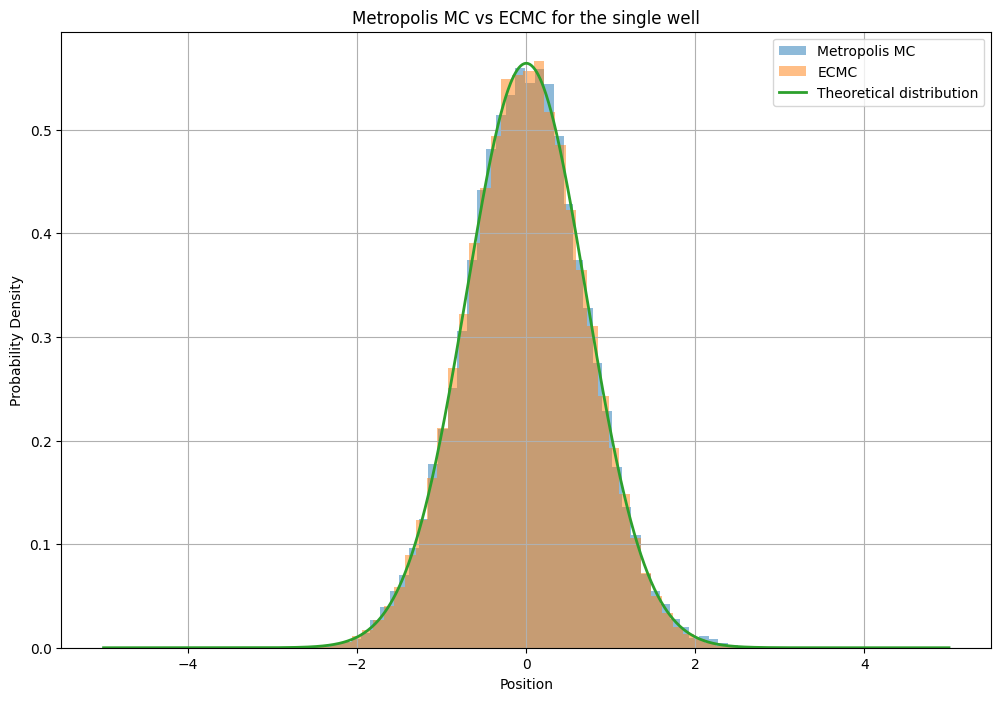

In [15]:
temperature = 1.0
burn_in = 1000

trajectory_mmc, acceptance_rate_mmc = metropolis_run(
    initial_x=5.0,
    num_steps=50_000,
    proposal_width=2.0,
    temperature=temperature
)

trajectory_ecmc = ecmc_run_single_well(
    initial_x=5.0,
    num_samples=50_000,
    distance_between_samples=1.0,
    temperature=temperature
)

samples_mmc = trajectory_mmc[burn_in:]
samples_ecmc = trajectory_ecmc[burn_in:]

x = np.linspace(-5, 5, 1000)
theoretical_dist = target_distribution(x, potential, temperature)

plt.figure(figsize=(12, 8))
plt.hist(samples_mmc, bins=50, density=True, alpha=0.5, label="Metropolis MC")
plt.hist(samples_ecmc, bins=50, density=True, alpha=0.5, label="ECMC")
plt.plot(x, theoretical_dist, linewidth=2, label="Theoretical distribution")
plt.xlabel("Position")
plt.ylabel("Probability Density")
plt.title("Metropolis MC vs ECMC for the single well")
plt.grid()
plt.legend()
plt.show()

Both Metropolis MC and ECMC appear to sample the same target distribution for the single-well potential,

$$
\pi_T(x)\propto \exp\left(-\frac{x^2}{T}\right).
$$

The histograms agree closely with the theoretical distribution, so the ECMC implementation seems to be sampling the correct equilibrium distribution in this simple case. This gives a useful baseline before moving to the double-well potential, where the main issue is not just matching the histogram but also moving efficiently between the two wells.

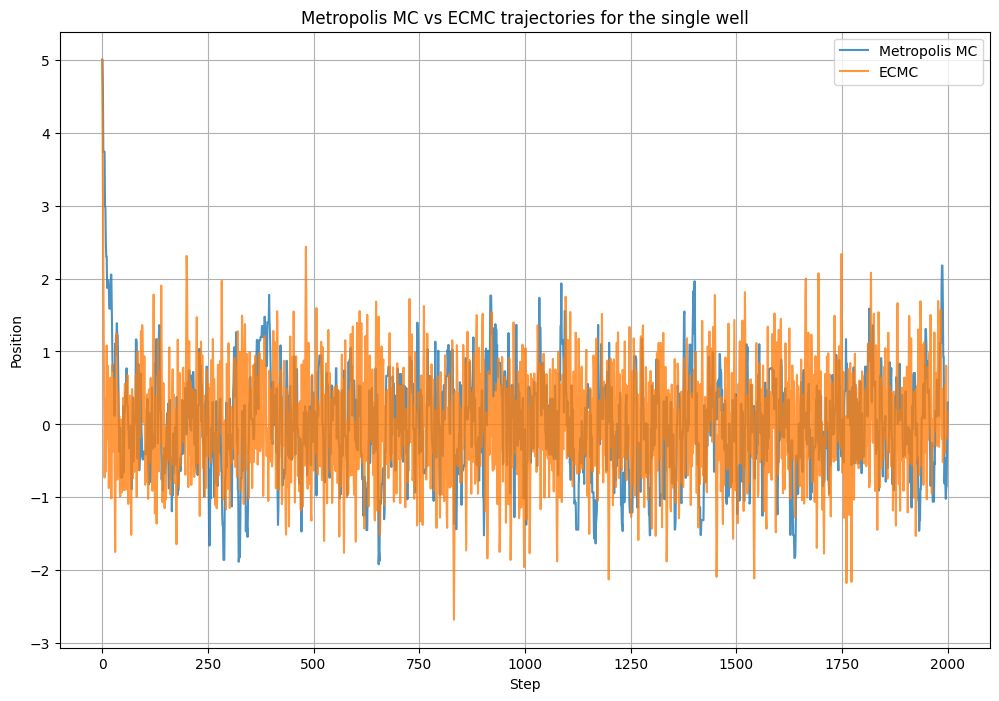

In [16]:
plt.figure(figsize=(12, 8))

plt.plot(trajectory_mmc[:2000], label="Metropolis MC", alpha=0.8)
plt.plot(trajectory_ecmc[:2000], label="ECMC", alpha=0.8)

plt.xlabel("Step")
plt.ylabel("Position")
plt.title("Metropolis MC vs ECMC trajectories for the single well")
plt.grid()
plt.legend()
plt.show()

In [17]:
def normalised_autocorrelation(samples, max_lag):
    """
    Compute the normalised autocorrelation function for a 1D sample.

    Args:
        samples (array-like): The 1D sample for which to compute the autocorrelation.
        max_lag (int): The maximum lag for which to compute the autocorrelation.

    Returns:
        array-like: The normalised autocorrelation function.
    """
    samples = np.asarray(samples)
    samples = samples - np.mean(samples)

    autocorr_full = np.correlate(samples, samples, mode="full")
    autocorr = autocorr_full[autocorr_full.size // 2:]
    autocorr = autocorr[:max_lag + 1]

    return autocorr / autocorr[0]


def estimate_iact(autocorr):
    """
    Estimate the integrated autocorrelation time using the first point,
    where the autocorrelation becomes negative as a cutoff.

    Args:
        autocorr (array-like): The autocorrelation function.

    Returns:
        float: The estimated integrated autocorrelation time.
    """
    negative_indices = np.where(autocorr < 0)[0]

    if len(negative_indices) == 0:
        cutoff = len(autocorr)
    else:
        cutoff = negative_indices[0]

    return 1 + 2 * np.sum(autocorr[1:cutoff])

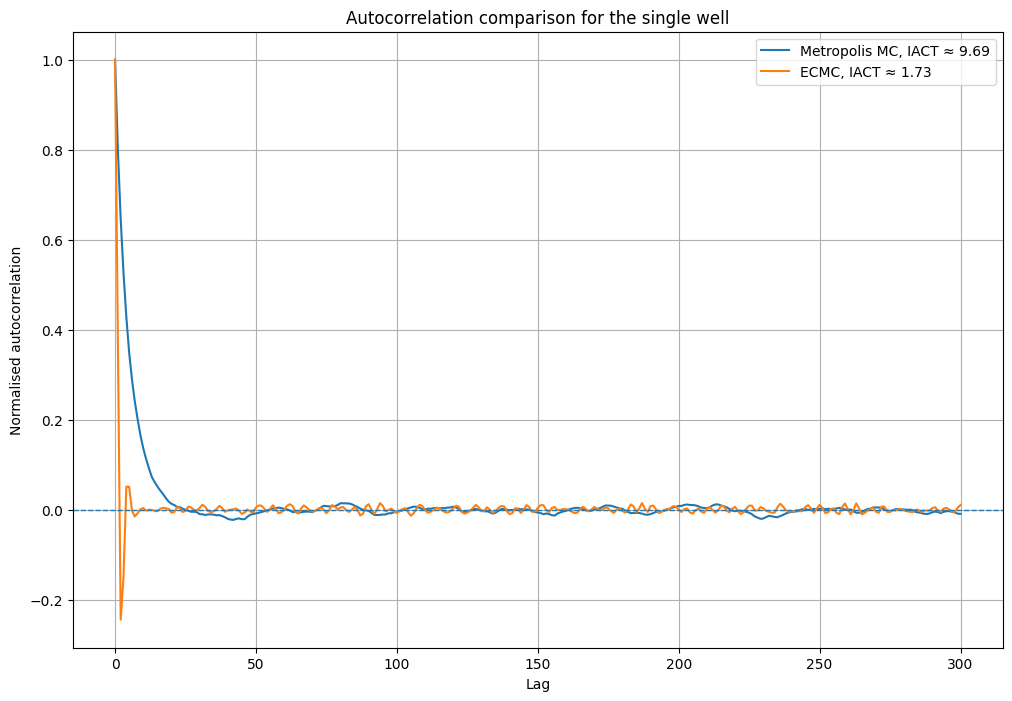

Metropolis MC IACT: 9.691
ECMC IACT: 1.733


In [18]:
max_lag = 300

acf_mmc = normalised_autocorrelation(samples_mmc, max_lag)
acf_ecmc = normalised_autocorrelation(samples_ecmc, max_lag)

iact_mmc = estimate_iact(acf_mmc)
iact_ecmc = estimate_iact(acf_ecmc)

lags = np.arange(max_lag + 1)

plt.figure(figsize=(12, 8))
plt.plot(lags, acf_mmc, label=f"Metropolis MC, IACT ≈ {iact_mmc:.2f}")
plt.plot(lags, acf_ecmc, label=f"ECMC, IACT ≈ {iact_ecmc:.2f}")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag")
plt.ylabel("Normalised autocorrelation")
plt.title("Autocorrelation comparison for the single well")
plt.grid()
plt.legend()
plt.show()

print(f"Metropolis MC IACT: {iact_mmc:.3f}")
print(f"ECMC IACT: {iact_ecmc:.3f}")

## Event-chain Monte Carlo for the double well

For the double-well potential

$$
U(x)=-\frac{a}{2}x^2+\frac{b}{4}x^4,
$$

we have

$$
\frac{dU}{dx}=-ax+bx^3.
$$

So the ECMC event rate is

$$
\lambda(x,v)
=
\max\left(0,v\frac{dU}{dx}\right)
=
\max(0,v(-ax+bx^3)).
$$

As in the single-well case, only uphill motion contributes to the event rate. The main difference is that the double-well potential has two minima separated by a barrier, so this will test whether ECMC improves movement between the wells.

In [19]:
def dU_double_well(x, a=2.0, b=1.0):
    """
    Compute the derivative of the double-well potential.

    Args:
        x (float): The position at which to compute the derivative.
        a (float, optional): The coefficient of the linear term. Defaults to 2.0.
        b (float, optional): The coefficient of the cubic term. Defaults to 1.0.

    Returns:
        float: The derivative of the double-well potential at position x.
    """
    return -a*x + b*x**3

def get_critical_points_double_well(a=2.0, b=1.0):
    """
    Get the critical points of the double-well potential.

    Args:
        a (float, optional): The coefficient of the linear term. Defaults to 2.0.
        b (float, optional): The coefficient of the cubic term. Defaults to 1.0.

    Returns:
        array-like: The critical points of the double-well potential.
    """
    well_position = np.sqrt(a / b)
    return np.array([-well_position, 0.0, well_position])

def next_critical_point(current_x, velocity, a=2.0, b=1.0):
    """
    Find the next critical point in the direction of the velocity.

    Args:
        current_x (float): The current position.
        velocity (int): The direction of movement (+1 or -1).
        a (float, optional): The coefficient of the linear term. Defaults to 2.0.
        b (float, optional): The coefficient of the cubic term. Defaults to 1.0.

    Raises:
        ValueError: If the velocity is not +1 or -1.

    Returns:
        float or None: The position of the next critical point, or None if no such point exists.
    """
    critical_points = get_critical_points_double_well(a, b)

    if velocity == 1:
        ahead = critical_points[critical_points > current_x + 1e-12]
        if len(ahead) == 0:
            return None
        return np.min(ahead)

    if velocity == -1:
        ahead = critical_points[critical_points < current_x - 1e-12]
        if len(ahead) == 0:
            return None
        return np.max(ahead)

    raise ValueError("velocity must be either +1 or -1")

In [20]:
def solve_position_for_energy(x_left, x_right, target_energy, potential_func, increasing=True, tolerance=1e-10, max_iterations=100):
    """
    Solve for the position x such that potential_func(x) = target_energy using the bisection method.    

    Args:
        x_left (float): The left boundary of the search interval.
        x_right (float): The right boundary of the search interval.
        target_energy (float): The target energy value.
        potential_func (callable): The potential function for which to solve.
        increasing (bool, optional): Whether the potential is increasing. Defaults to True.
        tolerance (float, optional): The tolerance for the solution. Defaults to 1e-10.
        max_iterations (int, optional): The maximum number of iterations. Defaults to 100.

    Returns:
        float: The position x such that potential_func(x) = target_energy.
    """
    left = x_left
    right = x_right

    for _ in range(max_iterations):
        mid = 0.5 * (left + right)
        mid_energy = potential_func(mid)

        if increasing:
            if mid_energy < target_energy:
                left = mid
            else:
                right = mid
        else:
            if mid_energy < target_energy:
                right = mid
            else:
                left = mid

        if abs(right - left) < tolerance:
            break

    return 0.5 * (left + right)


def distance_to_next_event_double_well(current_x, velocity, temperature, a=2.0, b=1.0):
    """
    Calculate the distance to the next event in a double well potential.

    Args:
        current_x (float): The current position.
        velocity (float): The velocity.
        temperature (float): The temperature.
        a (float, optional): The parameter a. Defaults to 2.0.
        b (float, optional): The parameter b. Defaults to 1.0.

    Returns:
        float: The distance to the next event.
    """
    u = 1.0 - np.random.rand()
    remaining_uphill_energy = -temperature * np.log(u)

    distance_travelled = 0.0
    x = current_x

    def U(x_value):
        return U_double_well(x_value, a=a, b=b)

    while True:
        next_crit = next_critical_point(x, velocity, a=a, b=b)

        # If there is no critical point ahead, we are on an unbounded monotone branch.
        if next_crit is None:
            step = 1.0
            right_x = x + velocity * step

            # Increase the bracket until enough uphill energy is available.
            while U(right_x) - U(x) < remaining_uphill_energy:
                step *= 2.0
                right_x = x + velocity * step

            x_event = solve_position_for_energy(
                min(x, right_x),
                max(x, right_x),
                U(x) + remaining_uphill_energy,
                U,
                increasing=(velocity == 1)
            )

            return distance_travelled + abs(x_event - x)

        # Check whether moving from x to next_crit is uphill or downhill.
        midpoint = 0.5 * (x + next_crit)
        event_rate_sign = velocity * dU_double_well(midpoint, a=a, b=b)

        if event_rate_sign > 0:
            # This whole interval is uphill.
            available_uphill_energy = U(next_crit) - U(x)

            if remaining_uphill_energy <= available_uphill_energy:
                x_event = solve_position_for_energy(
                    min(x, next_crit),
                    max(x, next_crit),
                    U(x) + remaining_uphill_energy,
                    U,
                    increasing=(velocity == 1)
                )

                return distance_travelled + abs(x_event - x)

            # Use all uphill energy available in this interval.
            remaining_uphill_energy -= available_uphill_energy

        # Move to the next critical point.
        distance_travelled += abs(next_crit - x)
        x = next_crit

In [21]:
def ecmc_run_double_well(initial_x, num_samples, distance_between_samples, temperature, a=2.0, b=1.0):
    """
    Run the ECMC algorithm for a double well potential.

    Args:
        initial_x (float): The initial position of the particle.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between consecutive samples.
        temperature (float): The temperature of the system.
        a (float, optional): The parameter a. Defaults to 2.0.
        b (float, optional): The parameter b. Defaults to 1.0.

    Returns:
        np.ndarray: An array of the generated positions.
    """
    current_x = initial_x
    velocity = np.random.choice([-1, 1])

    positions = [current_x]

    for _ in range(num_samples):
        distance_to_next_sample = distance_between_samples

        while distance_to_next_sample > 0:
            distance_to_event = distance_to_next_event_double_well(
                current_x,
                velocity,
                temperature,
                a=a,
                b=b
            )

            if distance_to_event < distance_to_next_sample:
                current_x += velocity * distance_to_event
                distance_to_next_sample -= distance_to_event
                velocity *= -1
            else:
                current_x += velocity * distance_to_next_sample
                distance_to_next_sample = 0

        positions.append(current_x)

    return np.array(positions)

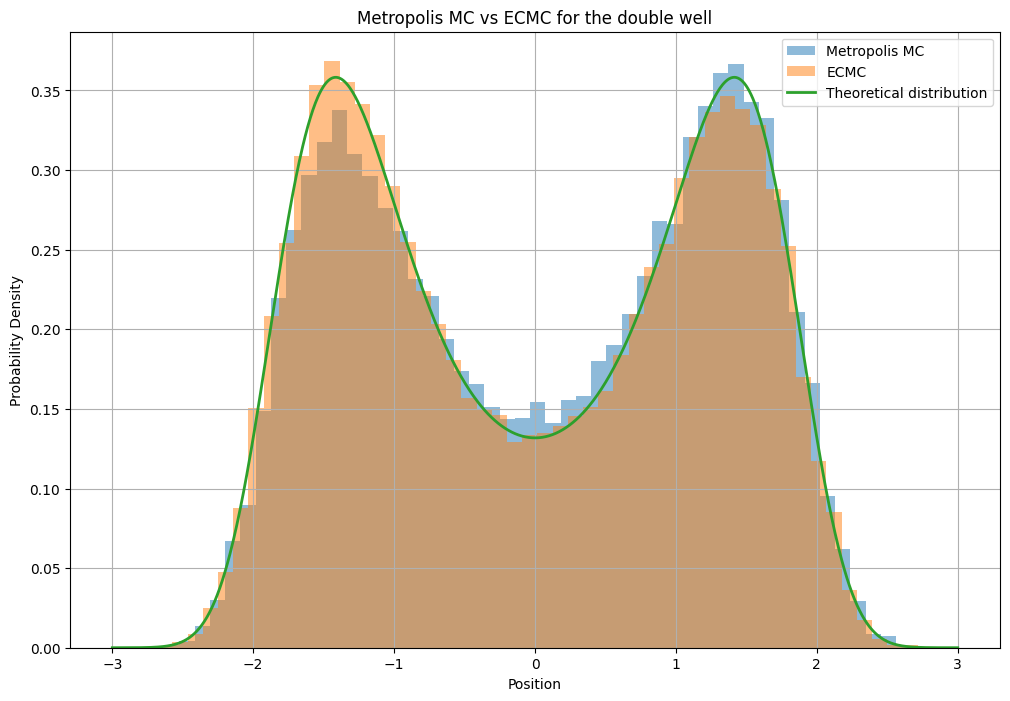

In [22]:
temperature = 1.0
burn_in = 1000

trajectory_mmc_double, acceptance_rate_mmc_double = metropolis_run(
    initial_x=0.0,
    num_steps=50_000,
    proposal_width=1.0,
    temperature=temperature,
    single=False,
    double=True
)

trajectory_ecmc_double = ecmc_run_double_well(
    initial_x=0.0,
    num_samples=50_000,
    distance_between_samples=1.0,
    temperature=temperature,
    a=2.0,
    b=1.0
)

samples_mmc_double = trajectory_mmc_double[burn_in:]
samples_ecmc_double = trajectory_ecmc_double[burn_in:]

x = np.linspace(-3, 3, 1000)
theoretical_dist = target_distribution(x, U_double_well, temperature)

plt.figure(figsize=(12, 8))
plt.hist(samples_mmc_double, bins=50, density=True, alpha=0.5, label="Metropolis MC")
plt.hist(samples_ecmc_double, bins=50, density=True, alpha=0.5, label="ECMC")
plt.plot(x, theoretical_dist, linewidth=2, label="Theoretical distribution")
plt.xlabel("Position")
plt.ylabel("Probability Density")
plt.title("Metropolis MC vs ECMC for the double well")
plt.grid()
plt.legend()
plt.show()

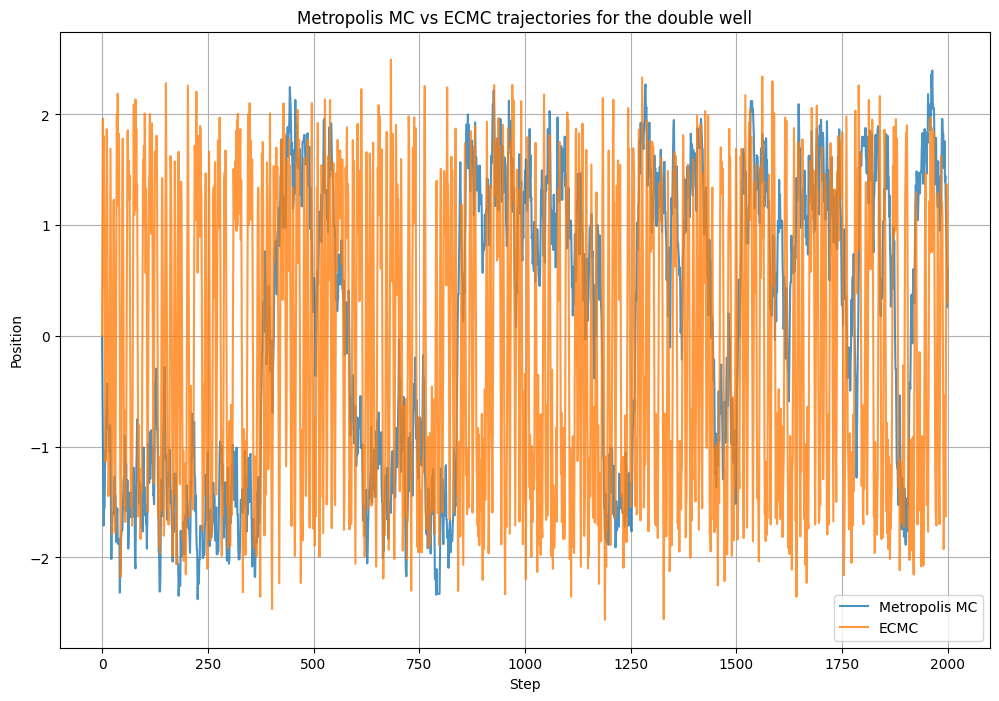

In [23]:
plt.figure(figsize=(12, 8))

plt.plot(trajectory_mmc_double[:2000], label="Metropolis MC", alpha=0.8)
plt.plot(trajectory_ecmc_double[:2000], label="ECMC", alpha=0.8)

plt.xlabel("Step")
plt.ylabel("Position")
plt.title("Metropolis MC vs ECMC trajectories for the double well")
plt.grid()
plt.legend()
plt.show()

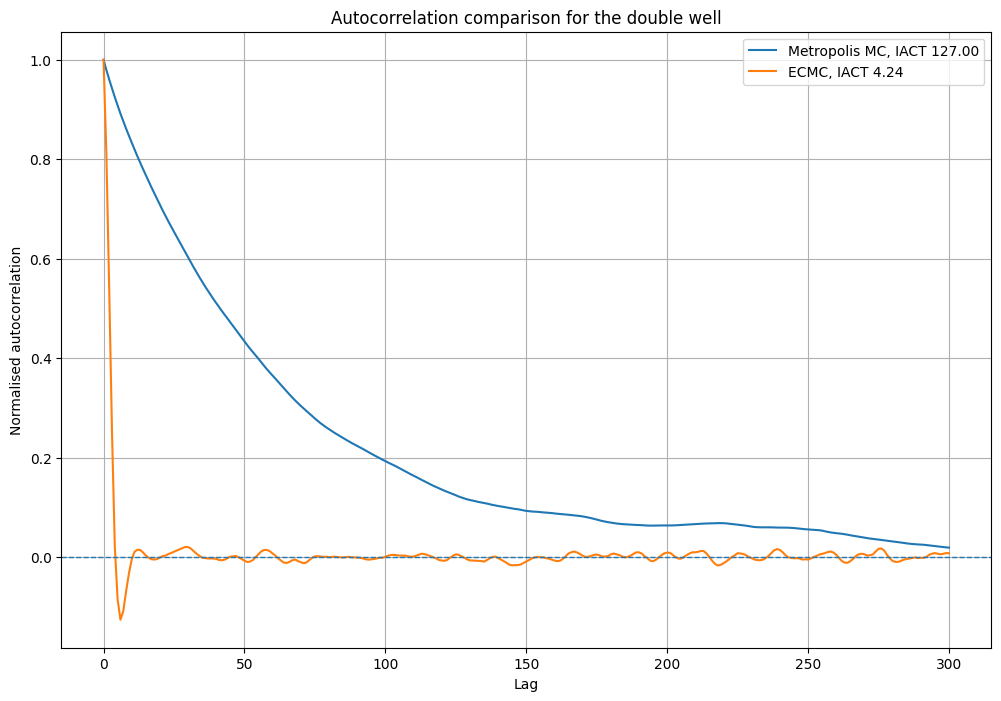

Metropolis MC double-well IACT: 126.996
ECMC double-well IACT: 4.245


In [24]:
max_lag = 300

acf_mmc_double = normalised_autocorrelation(samples_mmc_double, max_lag)
acf_ecmc_double = normalised_autocorrelation(samples_ecmc_double, max_lag)

iact_mmc_double = estimate_iact(acf_mmc_double)
iact_ecmc_double = estimate_iact(acf_ecmc_double)

lags = np.arange(max_lag + 1)

plt.figure(figsize=(12, 8))
plt.plot(lags, acf_mmc_double, label=f"Metropolis MC, IACT {iact_mmc_double:.2f}")
plt.plot(lags, acf_ecmc_double, label=f"ECMC, IACT {iact_ecmc_double:.2f}")
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Lag")
plt.ylabel("Normalised autocorrelation")
plt.title("Autocorrelation comparison for the double well")
plt.grid()
plt.legend()
plt.show()

print(f"Metropolis MC double-well IACT: {iact_mmc_double:.3f}")
print(f"ECMC double-well IACT: {iact_ecmc_double:.3f}")